# Neural Network - A Simple Perceptron | Assignment

### Question 1: What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning.

Deep Learning is a subset of Machine Learning that uses artificial neural networks with multiple hidden layers to learn complex patterns from large amounts of data automatically.

It mimics the structure of the human brain by using interconnected neurons organized in layers.

Evolution of Deep Learning

1950s–1960s:

Introduction of the Perceptron (Frank Rosenblatt).

1980s:

Backpropagation algorithm revived neural networks.

2006:

Geoffrey Hinton popularized deep belief networks.

2012:

AlexNet revolutionized image recognition using GPUs.

Present:

Deep Learning powers AI systems like computer vision, NLP, speech recognition.

| Traditional ML                      | Deep Learning                   |
| ----------------------------------- | ------------------------------- |
| Requires manual feature engineering | Automatically extracts features |
| Works well on small datasets        | Requires large datasets         |
| Algorithms: SVM, Decision Trees     | Neural Networks                 |
| Less computational power            | Requires GPUs/TPUs              |
| Interpretable models                | Less interpretable              |


### Question 2: Explain the basic architecture and functioning of a Perceptron. What are its limitations?

A Perceptron consists of:

>Input layer

>Weights

>Bias

>Activation function

Output

>Mathematical Representation

>>z=w1​x1​+w2​x2​+...+b

>>y=f(z)

>>Where:

>>>w = weights

>>>b = bias

>>>f = step activation function

Working

>Multiply inputs by weights

>Add bias

>Apply activation function

>Update weights using learning rule

Limitations

>Can only solve linearly separable problems

>Cannot solve XOR problem

>Binary output only

>No hidden layers

### Question 3: Describe the purpose of activation function in neural networks. Compare Sigmoid, ReLU, and Tanh functions.


Activation function:

Introduces non-linearity

Helps neural network learn complex patterns

Controls output range

| Function | Formula                   | Range  | Advantages      | Disadvantages      |
| -------- | ------------------------- | ------ | --------------- | ------------------ |
| Sigmoid  | 1/(1+e^-x)                | (0,1)  | Smooth output   | Vanishing gradient |
| Tanh     | (e^x - e^-x)/(e^x + e^-x) | (-1,1) | Zero centered   | Vanishing gradient |
| ReLU     | max(0,x)                  | [0,∞)  | Fast, efficient | Dying ReLU problem |


### Question 4: What is the difference between Loss function and Cost function in neural networks? Provide examples.

Loss Function

>Measures error for one training sample

Example:

>Binary Crossentropy

>Mean Squared Error

Cost Function

>Average of loss over entire dataset

>Cost=(1/N)​∑Loss

Example:

>Loss: Error for one image classification

>Cost: Average error for 60,000 MNIST images

### Question 5: What is the role of optimizers in neural networks? Compare Gradient Descent, Adam, and RMSprop.

Optimizers:

>Minimize loss function

>Update weights using gradients

| Optimizer        | Description                 | Pros               | Cons             |
| ---------------- | --------------------------- | ------------------ | ---------------- |
| Gradient Descent | Basic optimizer             | Simple             | Slow             |
| RMSprop          | Adaptive learning rate      | Faster convergence | Slightly complex |
| Adam             | Combines RMSprop + Momentum | Very efficient     | Memory usage     |


In [6]:
import warnings
warnings.filterwarnings('ignore')

### Question 6: Write a Python program to implement a single-layer perceptron from scratch using NumPy to solve the logical AND gate.

In [7]:
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])

weights = np.zeros(2)
bias = 0
learning_rate = 0.1

def step(x):
    return 1 if x >= 0 else 0

for epoch in range(10):
    for i in range(len(X)):
        z = np.dot(X[i], weights) + bias
        y_pred = step(z)
        error = y[i] - y_pred
        
        weights += learning_rate * error * X[i]
        bias += learning_rate * error

print("Weights:", weights)
print("Bias:", bias)

for i in range(len(X)):
    z = np.dot(X[i], weights) + bias
    print(X[i], "->", step(z))

Weights: [0.2 0.1]
Bias: -0.20000000000000004
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


### Question 7: Implement and visualize Sigmoid, ReLU, and Tanh activation functions using Matplotlib.

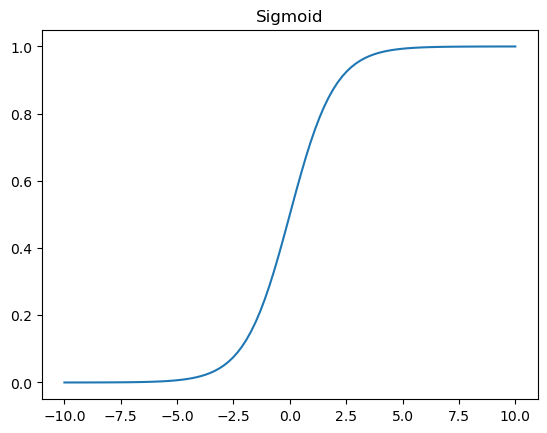

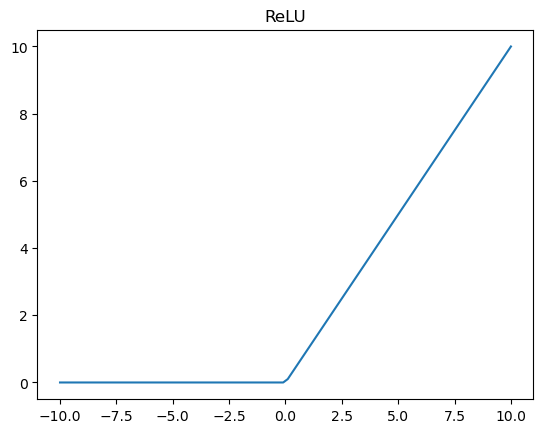

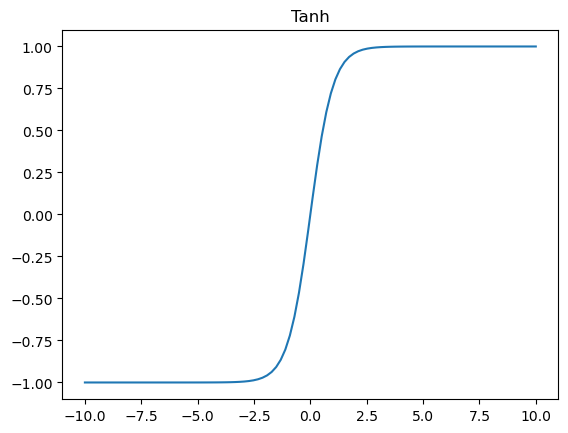

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10,10,100)

sigmoid = 1/(1+np.exp(-x))
relu = np.maximum(0,x)
tanh = np.tanh(x)

plt.figure()
plt.plot(x, sigmoid)
plt.title("Sigmoid")
plt.show()

plt.figure()
plt.plot(x, relu)
plt.title("ReLU")
plt.show()

plt.figure()
plt.plot(x, tanh)
plt.title("Tanh")
plt.show()

### Question 8: Use Keras to build and train a simple multilayer neural network on the MNIST digits dataset. Print the training accuracy.

In [9]:
import tensorflow as tf
from tensorflow import keras

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train/255.0
X_test = X_test/255.0

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)

loss, accuracy = model.evaluate(X_test, y_test)
print("Training Accuracy:", accuracy)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9304 - loss: 0.2362
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9694 - loss: 0.1007
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9781 - loss: 0.0710
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9827 - loss: 0.0548
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9857 - loss: 0.0434
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9748 - loss: 0.0906
Training Accuracy: 0.9747999906539917


### Question 9: Visualize the loss and accuracy curves for a neural network model trained on the Fashion MNIST dataset. Interpret the training behavior.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 22s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8242 - loss: 0.4970 - val_accuracy: 0.8373 - val_loss: 0.4536
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8655 - loss: 0.3743 - val_accuracy: 0.8639 - val_loss: 0.3786
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8784 - loss: 0.3378 - val_accuracy: 0.8680 - val_loss: 0.3721
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8851 - loss: 0.3136 - val_accuracy: 0.8704 - val_loss: 0.3548
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8917 - loss: 0.2939 - val_accuracy: 0.8743 - val_loss: 0.3512
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8968 - loss: 0.2802 - val_accuracy: 0.8710 - val_loss: 0.3649
Epoch 7/10
1875/1875 ━━━━━━━━━━

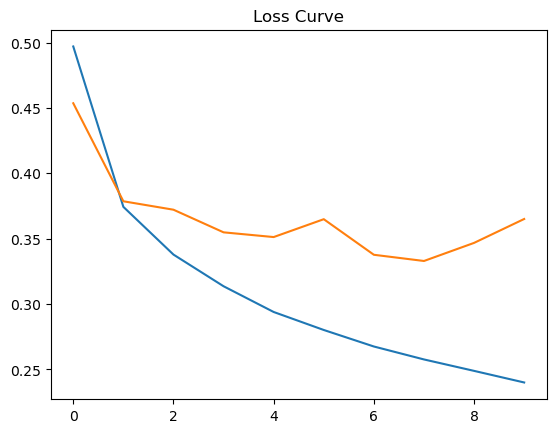

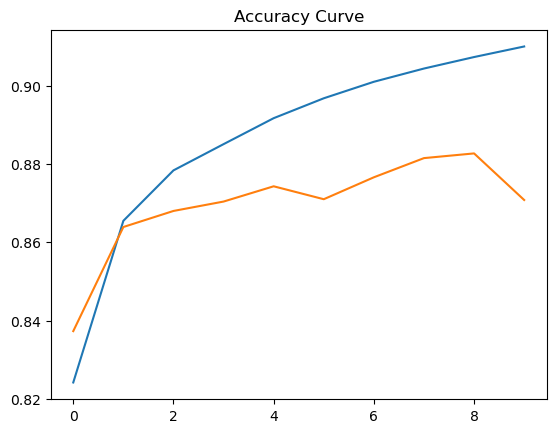

In [10]:
import matplotlib.pyplot as plt
from tensorflow import keras

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

X_train = X_train/255.0
X_test = X_test/255.0

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test,y_test))

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Curve")
plt.show()

### Question 10: You are working on a project for a bank that wants to automatically detect fraudulent transactions. The dataset is large, imbalanced, and contains structured features like transaction amount, merchant ID, and customer location. The goal is to classify each transaction as fraudulent or legitimate.
### Explain your real-time data science workflow:
>● How would you design a deep learning model (perceptron or multilayer NN)?

>● Which activation function and loss function would you use, and why?

>● How would you train and evaluate the model, considering class imbalance?

>● Which optimizer would be suitable, and how would you prevent overfitting?

Model Design

>Multilayer Neural Network

>Input layer (structured features)

>2–3 Dense layers (ReLU)

>Output layer (Sigmoid)

Activation & Loss

>Hidden layers: ReLU

>Output: Sigmoid

>Loss: Binary Crossentropy

>Reason:

>>Binary classification

>Sigmoid outputs probability (0–1)

Handling Class Imbalance

>Use:

>>Class weights

>>SMOTE

>>Precision, Recall, F1-score

>>ROC-AUC

>Accuracy alone is misleading.

Optimizer

>Adam (fast convergence)

Prevent Overfitting

>Dropout

>Early Stopping

>Regularization

>Cross-validation